# Script to assess and visualize the effect of different manual peak selection choices

by **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [1]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load manual peak ID data

In [2]:
# Load CSV files with peak detection results from all users
peakID_1 = pd.read_csv('peak_selection/SpikeIDs_1.csv').dropna()
peakID_2 = pd.read_csv('peak_selection/SpikeIDs_2.csv').dropna()
peakID_3 = pd.read_csv('peak_selection/SpikeIDs_3.csv').dropna()
peakID_4 = pd.read_csv('peak_selection/SpikeIDs_4.csv').dropna()

## Create long format matrix for later processing

In [3]:
# Calculate standard deviation of peak number by peak number
# First combine all dataframes into one long format
peak_dfs = [peakID_1, peakID_2, peakID_3, peakID_4] # Create a list of all dataframes

combined_peakID_long = pd.concat(peak_dfs, keys=['User1', 'User2', 'User3', 'User4'], names=['User', 'Index']).reset_index(level='User')
combined_peakID_long.head()

,User,Specimen,Spike 1,Spike 2,Spike 3,Spike 4,Spike 5,Spike 6,Spike 7
Index,,,,,,,,,
0,User1,B255,15.0,13.0,10.0,8.0,6.0,4.0,2.0
1,User1,B323,14.0,13.0,11.0,9.0,6.0,4.0,2.0
2,User1,B325,12.0,11.0,10.0,7.0,6.0,3.0,2.0
3,User1,G652,24.0,21.0,16.0,13.0,8.0,5.0,2.0
4,User1,G664,24.0,22.0,14.0,11.0,7.0,5.0,2.0


# Calculate and plot standard deviations of peak numbers

## Calculate standard deviation of peak number across specimen and peak#

In [26]:
# Compare differences in peak numbers identified for all specimens

# Initialize empty dataframe for standard deviations with same structure as input
peakID_std_df = pd.DataFrame(index=peakID_1.index, columns=peakID_1.columns)
peakID_std_df['Specimen'] = peakID_1['Specimen']

# Calculate standard deviation for each spike across all matrices
for column in peakID_1.columns:
    if column != 'Specimen':  # Skip the specimen column
        values = pd.concat([df[column] for df in peak_dfs], axis=1)
        peakID_std_df[column] = values.std(axis=1)

print("Standard deviations between peak identifications:")
print(peakID_std_df)

Standard deviations between peak identifications:
   Specimen   Spike 1   Spike 2   Spike 3   Spike 4   Spike 5   Spike 6  \
0      B255  0.500000  2.000000  0.957427  0.577350  0.577350  0.000000   
1      B323  0.000000  1.000000  1.258306  1.154701  0.000000  0.000000   
2      B325  0.500000  0.000000  0.000000  0.000000  0.500000  0.000000   
3      G652  3.696846  3.947573  2.061553  2.380476  2.061553  2.061553   
4      G664  0.500000  1.290994  1.500000  1.500000  2.000000  2.061553   
5      G668  1.258306  2.000000  2.160247  0.500000  1.000000  0.000000   
6      G691  0.500000  0.577350  2.061553  0.957427  0.500000  0.957427   
7      G717  2.380476  2.886751  1.500000  2.500000  0.000000  0.000000   
8      G719  0.957427  1.000000  0.000000  0.577350  1.732051  0.957427   
9      G723  0.000000  0.500000  0.000000  0.000000  0.000000  0.577350   
10     G728  1.000000  2.500000  0.500000  0.000000  0.577350  1.154701   
11     G730  1.500000  1.154701  1.732051  2.06155

## Plot heatmap of standard deviations across peak # and specimen

Text(0.5, 1.0, 'Standard Deviation of Peak Numbers Identified by Different Users')

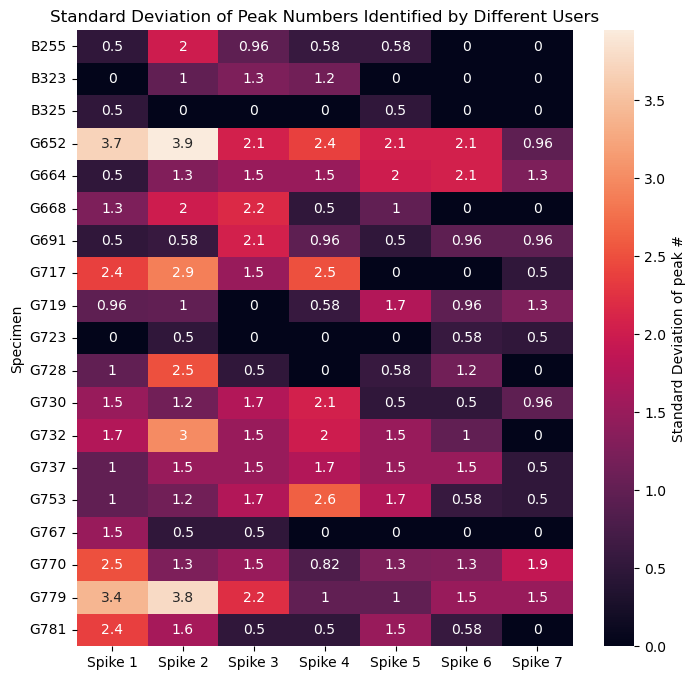

In [27]:
# Plot heatmap of standard deviations across peak # and specimen
plt.figure(figsize=(8, 8))
sns.heatmap(std_df.set_index('Specimen').astype(float), annot = True, cbar_kws={'label': 'Standard Deviation of peak #'})
plt.title('Standard Deviation of Peak Numbers Identified by Different Users')

## Calculate standard deviations per peak number

In [28]:
# Calculate standard deviation of peak number per peak combined across specimens
std_by_peak = peakID_std_df.drop(columns=['Specimen']).std()
std_by_peak_df = pd.DataFrame({'Peak Number': std_by_peak.index, 'Standard Deviation': std_by_peak.values})
print("Standard deviation of peak numbers across specimens:")
print(std_by_peak_df)

Standard deviation of peak numbers across specimens:
  Peak Number  Standard Deviation
0     Spike 1            1.063771
1     Spike 2            1.112225
2     Spike 3            0.756542
3     Spike 4            0.896117
4     Spike 5            0.709593
5     Spike 6            0.694657
6     Spike 7            0.606980


## Plot standard deviations per spike

Text(0.5, 1.0, 'Standard Deviation of Peak Numbers by Peak')

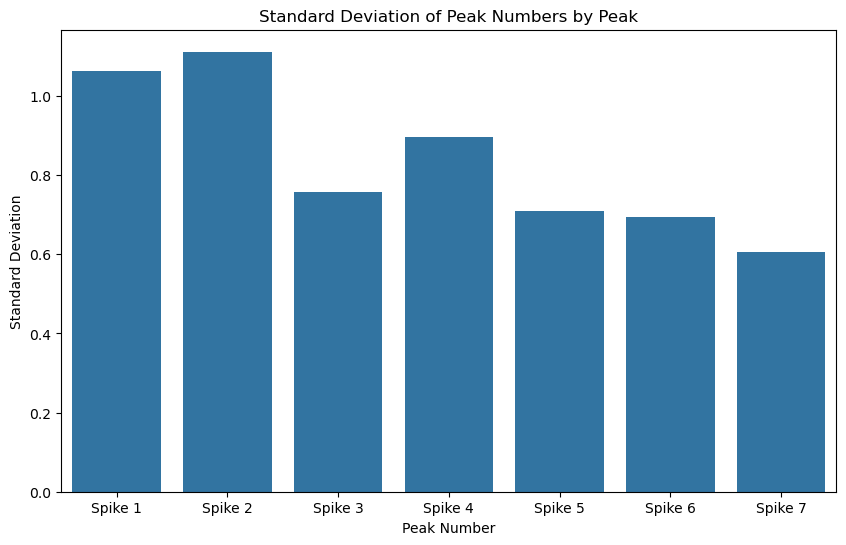

In [29]:
# Plot bar chart of standard deviations per peak
plt.figure(figsize=(10, 6))
sns.barplot(data=std_by_peak_df, x='Peak Number', y='Standard Deviation')
plt.title('Standard Deviation of Peak Numbers by Peak')

## Calculate standard deviations per specimen

In [30]:
# Calculate standard deviation of peak number per specimen combined across peaks
std_by_specimen = peakID_std_df.set_index('Specimen').std(axis=1) # Standard deviation across columns (peaks)
std_by_specimen_df = pd.DataFrame({'Specimen': std_by_specimen.index, 'Standard Deviation': std_by_specimen.values})
print("Standard deviation of peak numbers across peaks:")
print(std_by_specimen_df)

Standard deviation of peak numbers across peaks:
   Specimen  Standard Deviation
0      B255            0.682461
1      B323            0.612723
2      B325            0.243975
3      G652            1.039438
4      G664            0.523738
5      G668            0.881471
6      G691            0.544186
7      G717            1.232992
8      G719            0.539541
9      G723            0.282223
10     G728            0.863413
11     G730            0.599478
12     G732            0.917075
13     G737            0.423119
14     G753            0.753674
15     G767            0.556349
16     G770            0.544989
17     G779            1.128777
18     G781            0.835271


## Plot standard deviations per specimen

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'B255'),
  Text(1, 0, 'B323'),
  Text(2, 0, 'B325'),
  Text(3, 0, 'G652'),
  Text(4, 0, 'G664'),
  Text(5, 0, 'G668'),
  Text(6, 0, 'G691'),
  Text(7, 0, 'G717'),
  Text(8, 0, 'G719'),
  Text(9, 0, 'G723'),
  Text(10, 0, 'G728'),
  Text(11, 0, 'G730'),
  Text(12, 0, 'G732'),
  Text(13, 0, 'G737'),
  Text(14, 0, 'G753'),
  Text(15, 0, 'G767'),
  Text(16, 0, 'G770'),
  Text(17, 0, 'G779'),
  Text(18, 0, 'G781')])

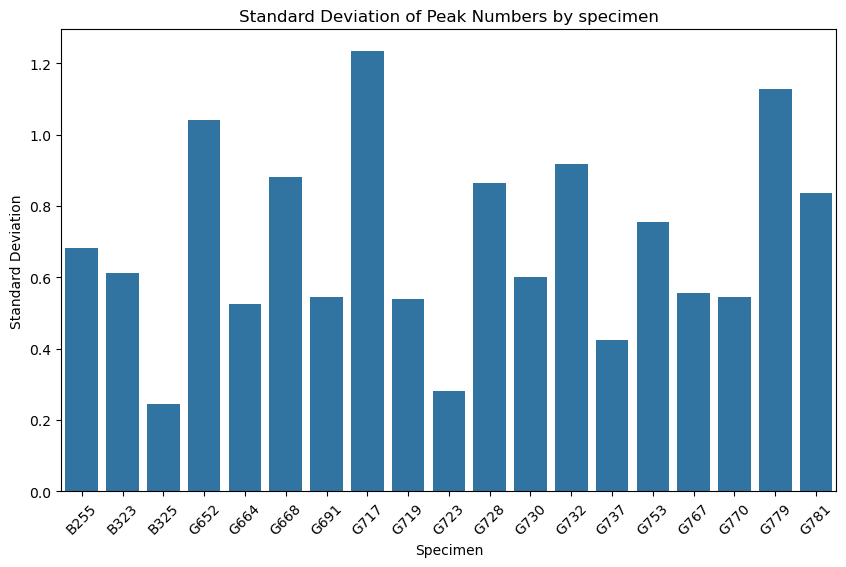

In [31]:
# Plot bar chart of standard deviations per specimen
plt.figure(figsize=(10, 6))
sns.barplot(data=std_by_specimen_df, x='Specimen', y='Standard Deviation')
plt.title('Standard Deviation of Peak Numbers by specimen')
plt.xticks(rotation=45)

# Plot peak number spread per specimen

     User    Spike  Value
0   User1  Spike 1   15.0
1   User2  Spike 1   16.0
2   User3  Spike 1   16.0
3   User4  Spike 1   16.0
4   User1  Spike 2   13.0
5   User2  Spike 2    9.0
6   User3  Spike 2   13.0
7   User4  Spike 2   13.0
8   User1  Spike 3   10.0
9   User2  Spike 3    8.0
10  User3  Spike 3    9.0
11  User4  Spike 3   10.0
12  User1  Spike 4    8.0
13  User2  Spike 4    7.0
14  User3  Spike 4    8.0
15  User4  Spike 4    7.0
16  User1  Spike 5    6.0
17  User2  Spike 5    5.0
18  User3  Spike 5    6.0
19  User4  Spike 5    5.0
20  User1  Spike 6    4.0
21  User2  Spike 6    4.0
22  User3  Spike 6    4.0
23  User4  Spike 6    4.0
24  User1  Spike 7    2.0
25  User2  Spike 7    2.0
26  User3  Spike 7    2.0
27  User4  Spike 7    2.0
     User    Spike  Value
0   User1  Spike 1   14.0
1   User2  Spike 1   14.0
2   User3  Spike 1   14.0
3   User4  Spike 1   14.0
4   User1  Spike 2   13.0
5   User2  Spike 2   13.0
6   User3  Spike 2   11.0
7   User4  Spike 2   13.0
8   User1  S

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Spike 1'),
  Text(1, 0, 'Spike 2'),
  Text(2, 0, 'Spike 3'),
  Text(3, 0, 'Spike 4'),
  Text(4, 0, 'Spike 5'),
  Text(5, 0, 'Spike 6'),
  Text(6, 0, 'Spike 7')])

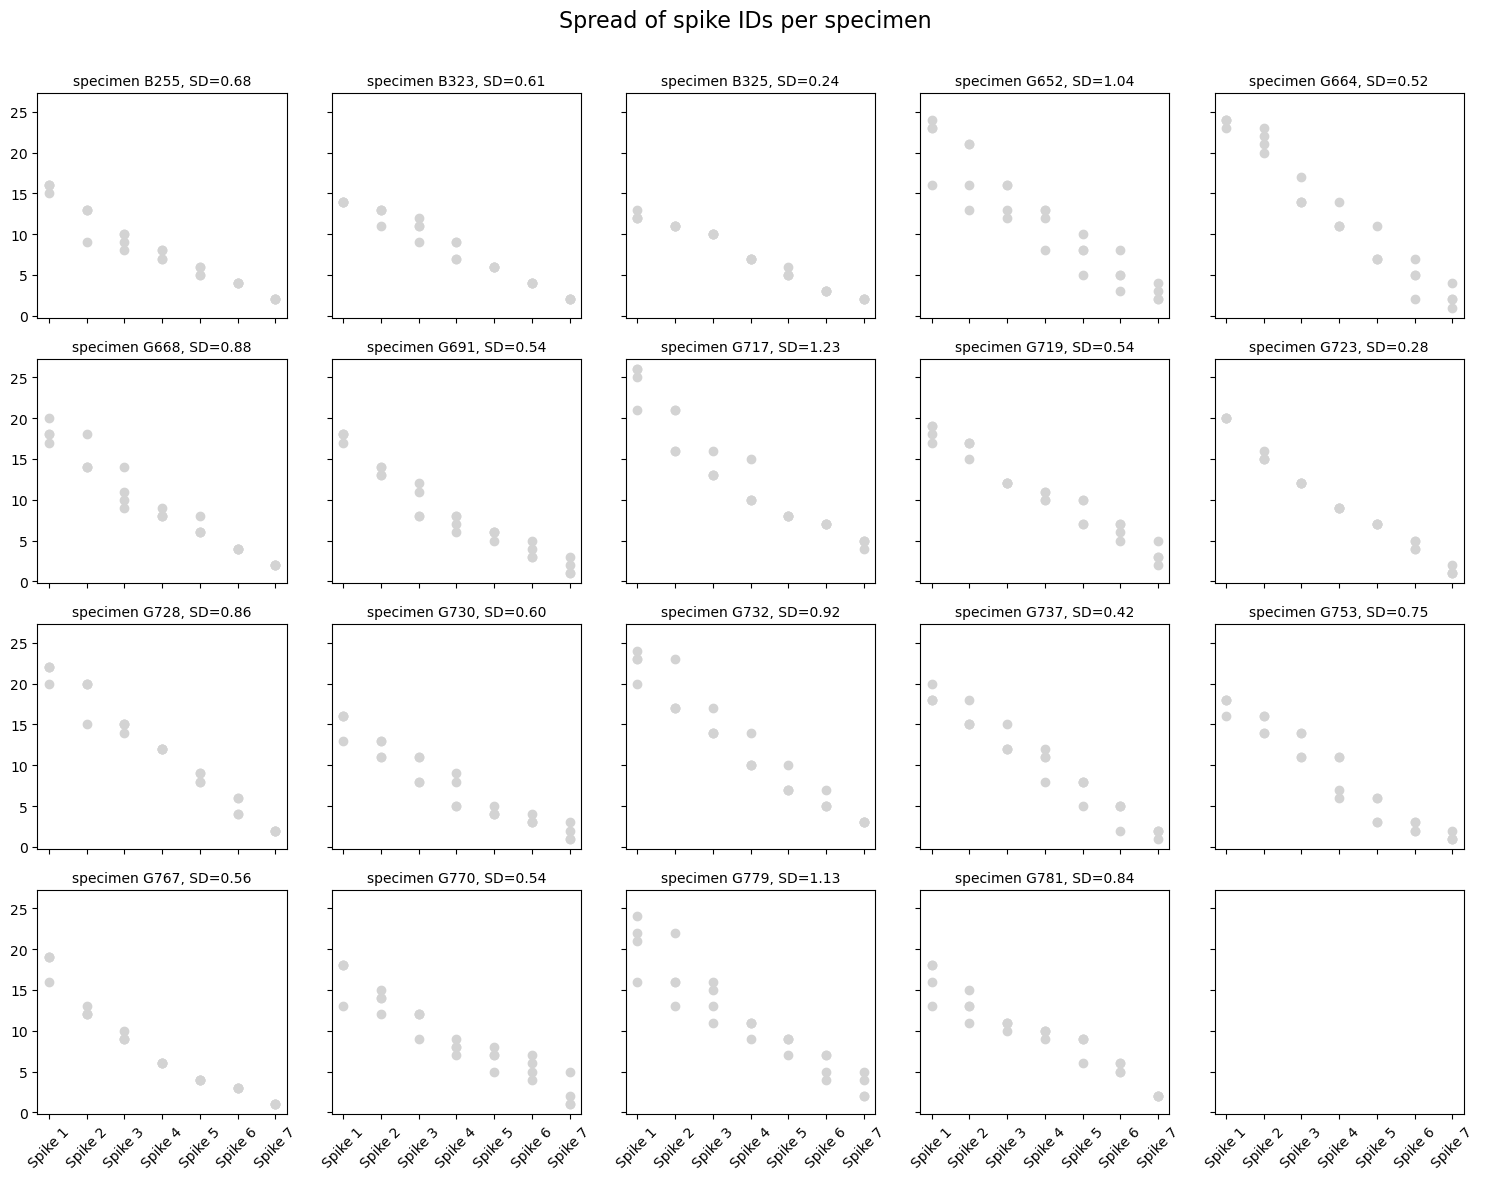

In [49]:
# Plot spread of peak numbers per specimen
specimens = combined_peakID_long['Specimen'].unique()
fig, axes = plt.subplots(4, 5, figsize=(15, 12), sharey=True, sharex=True)
axes = axes.flatten()

for i, spec in enumerate(specimens):
    ax = axes[i]
    data = combined_peakID_long.loc[combined_peakID_long['Specimen'] == spec, :]

    # Melt the spike columns into a long format for plotting
    spike_columns = [col for col in data.columns if 'Spike' in col]
    melted_data = data.melt(id_vars=['User'], value_vars=spike_columns, var_name='Spike', value_name='Value')

    print(melted_data)
    # # Create scatter plot of spike number vs spike value
    ax.plot(melted_data.Spike, melted_data.Value, color='lightgray', marker='o', linestyle='None')
    ax.set_title(f'specimen {spec}, SD={std_by_specimen_df.loc[std_by_specimen_df["Specimen"] == spec, "Standard Deviation"].values[0]:.2f}', fontsize=10) # Add standard deviation to title
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Spread of spike IDs per specimen', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.xticks(rotation=45)


## Calculate unique peakIDs per specimen

In [58]:
# Calculate unique peakIDs per specimen
# Melt the spike columns into a long format for plotting
spike_columns = [col for col in combined_peakID_long.columns if 'Spike' in col]
melted_data_all = combined_peakID_long.melt(id_vars=['Specimen'], value_vars=spike_columns, var_name='Spike', value_name='Value')
unique_peakIDs_per_specimen = melted_data_all.groupby('Specimen')['Value'].nunique()
unique_peakIDs_per_specimen_df = pd.DataFrame({'Specimen': unique_peakIDs_per_specimen.index, 'Unique Peak IDs': unique_peakIDs_per_specimen.values})
print("Unique peak IDs per specimen:")
print(unique_peakIDs_per_specimen_df)

Unique peak IDs per specimen:
   Specimen  Unique Peak IDs
0      B255               11
1      B323                9
2      B325                9
3      G652               12
4      G664               13
5      G668               11
6      G691               14
7      G717               11
8      G719               12
9      G723               10
10     G728               10
11     G730               10
12     G732                9
13     G737                9
14     G753                9
15     G767               10
16     G770               13
17     G779               12
18     G781               10


## Plot unique peakID numbers per specimen

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'B255'),
  Text(1, 0, 'B323'),
  Text(2, 0, 'B325'),
  Text(3, 0, 'G652'),
  Text(4, 0, 'G664'),
  Text(5, 0, 'G668'),
  Text(6, 0, 'G691'),
  Text(7, 0, 'G717'),
  Text(8, 0, 'G719'),
  Text(9, 0, 'G723'),
  Text(10, 0, 'G728'),
  Text(11, 0, 'G730'),
  Text(12, 0, 'G732'),
  Text(13, 0, 'G737'),
  Text(14, 0, 'G753'),
  Text(15, 0, 'G767'),
  Text(16, 0, 'G770'),
  Text(17, 0, 'G779'),
  Text(18, 0, 'G781')])

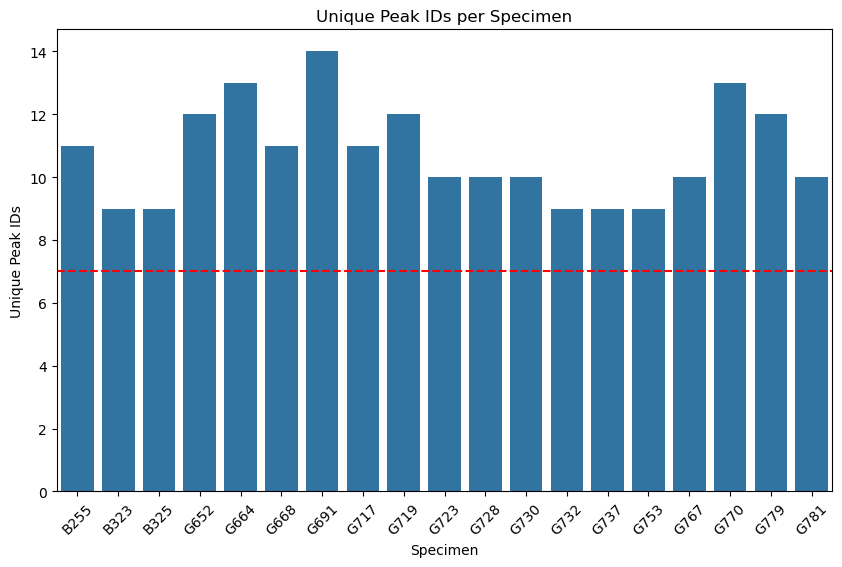

In [60]:
# Bar plot of unique peakID numbers per specimen with line indicating ideal agreement (unique peak IDs = 7)
plt.figure(figsize=(10, 6))
sns.barplot(data=unique_peakIDs_per_specimen_df, x='Specimen', y='Unique Peak IDs')
plt.axhline(y=7, color='r', linestyle='--', label='Ideal Agreement (7 Peak IDs)')
plt.title('Unique Peak IDs per Specimen')
plt.xticks(rotation=45)